# <center>$~~~~~$A Study on Selecting Stocks Suitable for SMA Strategy Based on Fundamental and Trading Indicators$~~~~~$</center>

### $~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$ By Group 7

$~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$胡万妮  2130018019
$~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$艾子为  2130018001
$~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$蒙蕙煊  2130018043

---

## <center>------------------------------------------------------  Overall Strategy  ------------------------------------------------------</center>

## Research Purpose
### This research aims to screen stocks that are suitable for the Simple Moving Average (SMA) strategy by conducting a comprehensive analysis of fundamental and trading indicators. By identifying stocks with strong fundamentals and price trends, the research aims to provide investors with wiser investment choices.

## Research approach

![MINDMAP](MindMap.PNG)

## <center>---------------------------------------------------  Code Implementation  ---------------------------------------------------</center>

### Import Module

In [1]:
import pandas as pd
import tushare as ts
import numpy as np
import datetime
import time
from dateutil.relativedelta import relativedelta # For large-scale time addition and subtraction
from time import sleep
import talib as tb
import matplotlib.pyplot as plt 

### Date Processed

#### If you want use recently data to run this strategy, we support you use this part code as timeset.

In [2]:
# today = datetime.datetime.today().strftime('%Y%m%d')    #Today

# lastday = datetime.datetime.today() - datetime.timedelta(days=1)  #Last Day
# lastday = lastday.strftime('%Y%m%d')

# last_year = datetime.datetime.today() - relativedelta(months=12)   #Last Year
# last_year = last_year.strftime('%Y%m%d')   # Transfer to STR

# last_2year = datetime.datetime.today() - relativedelta(years=2)   #Last Two Years
# last_2year = last_2year.strftime('%Y%m%d')   # Transfer to STR

# Lastweek = datetime.datetime.today() - datetime.timedelta(days=7)   #Last week
# Lastweek = Lastweek.strftime('%Y%m%d')    # Transfer to STR

# last_mon = datetime.datetime.today() - relativedelta(months=1)   #Last Month
# last_mon = last_mon.strftime('%Y%m%d')   # Transfer to STR

### Time Set  
#### Choose the period from 2019 to 2020 to implement our screening model, and used data from 2020 to 2021 for backtesting.

In [3]:
today = '20200101'
lastday = '20191231'
last_year = '20190101'
last_2year = '20180101'
Lastweek = '20191225'
last_mon = '20191201'

# <center>---  Stock Picking  ---</center>

## 1 Data preprocessing — Selecting Stocks from the A shares 

#### Selection condition  
- Remove ST stocks 
- Remove GEM stocks 
- Remove stocks that have been on the market for less than two years   
- Remove suspended stocks

In [4]:
ts.set_token(os.getenv('TUSHARE_TOKEN'))
pro=ts.pro_api()

In [5]:
sts = []
cys = []
kcs = []
all_stock = []
stmp = time.localtime()

In [6]:
# Stock Data
data = pro.query('stock_basic', exchange='', list_status='L', \
fields='ts_code,symbol,name,area,industry,list_date')

# Remove ST stocks
st_data = data[data.name.str.contains('ST')]    
sts = st_data['name'].values.tolist() 
for st in sts:
    data = data.drop(index=(data.loc[(data['name'] == st)].index))

# Remove GEM stocks
cy_data = data[data.ts_code.str.contains('^30')]  
cys = cy_data['ts_code'].values.tolist()  
for cy in cys:
    data = data.drop(index=(data.loc[(data['ts_code'] == cy)].index))

# Remove Stocks that have been on the market for less than two years
data = data[data['list_date']<last_2year]

# Remove suspended stocks
tp_df = pro.suspend_d(suspend_type = 'S', trade_date = today)
tp_list = tp_df['ts_code'].values.tolist()
for tp in tp_list:
    data = data.drop(index=(data.loc[(data['ts_code'] == tp)].index))

# Selected stock codes are stored in list：all_stock
all_stock = data['ts_code'].values.tolist()

In [7]:
all_stock

['000001.SZ',
 '000002.SZ',
 '000004.SZ',
 '000006.SZ',
 '000008.SZ',
 '000009.SZ',
 '000010.SZ',
 '000011.SZ',
 '000012.SZ',
 '000014.SZ',
 '000016.SZ',
 '000017.SZ',
 '000019.SZ',
 '000020.SZ',
 '000021.SZ',
 '000025.SZ',
 '000026.SZ',
 '000027.SZ',
 '000028.SZ',
 '000029.SZ',
 '000030.SZ',
 '000031.SZ',
 '000032.SZ',
 '000034.SZ',
 '000035.SZ',
 '000036.SZ',
 '000037.SZ',
 '000039.SZ',
 '000040.SZ',
 '000042.SZ',
 '000045.SZ',
 '000048.SZ',
 '000049.SZ',
 '000050.SZ',
 '000055.SZ',
 '000056.SZ',
 '000058.SZ',
 '000059.SZ',
 '000060.SZ',
 '000061.SZ',
 '000062.SZ',
 '000063.SZ',
 '000065.SZ',
 '000066.SZ',
 '000068.SZ',
 '000069.SZ',
 '000078.SZ',
 '000088.SZ',
 '000089.SZ',
 '000090.SZ',
 '000096.SZ',
 '000099.SZ',
 '000100.SZ',
 '000151.SZ',
 '000153.SZ',
 '000155.SZ',
 '000156.SZ',
 '000157.SZ',
 '000158.SZ',
 '000159.SZ',
 '000166.SZ',
 '000301.SZ',
 '000333.SZ',
 '000338.SZ',
 '000400.SZ',
 '000401.SZ',
 '000402.SZ',
 '000403.SZ',
 '000404.SZ',
 '000407.SZ',
 '000408.SZ',
 '0004

## 2 Quantitative stock selection by fundamental factors

### 2.1 Get financial data on selected stocks

#### Financial data
- Basic subjects:  
finaexp_of_gr (Finance expenses/total revenue), current_exint (Non-interest bearing current liabilities), netdebt(net debt)  
The above data is taken as a small value.
- Per share indicator factors:  
undist_profit_ps (Undistributed profit per share), q_eps (earnings per share), surplus_rese_ps(Earnings per share reserve)  
The above data is taken as the largest value.
- Value factors:  
ar_turn(turnover of account receivable), cogs_of_sales(ratio of sales to cost), debt_to_eqt(equity ratio)  
The above data is taken as a small value.

In [8]:
# Create a new DataFrame
all_dataframe = pd.DataFrame()

# Import data from tushare
for stock in all_stock:

    df1 = pro.fina_indicator(ts_code = stock,start_date= last_year, end_date=today, fields='ts_code,end_date,finaexp_of_gr,current_exint,netdebt,undist_profit_ps,q_eps,surplus_rese_ps,ar_turn,cogs_of_sales,debt_to_eqt')
    # There may be multiple financial statements in a period of time. 
    # Take the first representative in the head and take the most recent statement
    df1 = df1.head(1)   
    all_dataframe = all_dataframe.append(df1)
    # Limited by the frequency of visits per minute, each query takes a 1 second break
    sleep(1)  

# Reset index
all_dataframe = all_dataframe.reset_index()  

# Delete original index
all_dataframe = all_dataframe.drop(columns = ['index']) 

# Delete empty values
all_dataframe = all_dataframe.dropna(axis=0, how='any')
all_dataframe

,ts_code,end_date,surplus_rese_ps,undist_profit_ps,ar_turn,current_exint,netdebt,cogs_of_sales,finaexp_of_gr,debt_to_eqt,q_eps
1,000002.SZ,20191231,6.2666,8.4366,205.858,1.1761e+12,1.1556e+11,63.7549,1.5591,5.3934,1.8254
2,000004.SZ,20191231,0.0813,0.0858,0.7426,8.55646e+07,-1.47844e+08,26.9898,-1.5441,0.0641,0.0790
3,000006.SZ,20191231,1.3315,2.2991,317.619,4.42792e+09,1.10789e+09,54.7879,3.4202,1.1959,0.2588
4,000008.SZ,20191231,0.0179,0.7455,0.9609,2.07538e+09,9.68423e+08,51.3633,2.9402,0.5897,0.1028
5,000009.SZ,20191231,0.1077,0.8685,4.9914,5.83708e+09,6.17466e+09,64.8911,4.0554,1.8213,0.0389
...,...,...,...,...,...,...,...,...,...,...,...
2487,603991.SH,20191231,0.2326,1.0679,1.7501,7.29757e+07,1.71112e+08,88.4779,3.5204,0.646,-0.6437
2488,603993.SH,20191231,0.0596,0.3742,43.6619,8.07928e+09,3.24939e+10,95.5285,1.8213,1.3611,0.0284
2489,603997.SH,20191231,0.1773,0.7659,13.4973,3.77003e+09,4.63873e+09,84.4216,1.2963,2.5709,0.1048
2490,603998.SH,20191231,0.1602,1.1704,8.3895,4.13453e+08,1.49852e+08,27.3887,0.3655,0.6591,0.0195


### 2.2 Quantification and equalization of each stock through financial data

#### Scoring steps
- Data processing: delect extremum
- Calculate quantile
    - If the data requires a small value，we calculate 20% quantile.
    - If the data requires a big value，we calculat 80% quantile.
- The stock data is compared to the quantile, and if the data for the stock meets the conditions, the stock is added one point.
- Finally, calculate and rank stock scores.

**Data processing**

In [9]:
# Get data for each stock
# delect extremum
# 3x median depolarizing
def _3mad(nums):
    mad = np.median(nums)
    up = mad + 3 * mad
    down = mad - 3 * mad
    nums = np.where(nums > up,up,nums)
    nums = np.where(nums < down,down,nums)
    return nums

all_dataframe['finaexp_of_gr'] = _3mad(all_dataframe[['finaexp_of_gr'][0]])
all_dataframe['current_exint'] = _3mad(all_dataframe[['current_exint'][0]])
all_dataframe['netdebt'] = _3mad(all_dataframe[['netdebt'][0]])

all_dataframe['undist_profit_ps'] = _3mad(all_dataframe[['undist_profit_ps'][0]])
all_dataframe['q_eps'] = _3mad(all_dataframe[['q_eps'][0]])
all_dataframe['surplus_rese_ps'] = _3mad(all_dataframe[['surplus_rese_ps'][0]])

all_dataframe['ar_turn'] = _3mad(all_dataframe[['ar_turn'][0]])
all_dataframe['cogs_of_sales'] = _3mad(all_dataframe[['cogs_of_sales'][0]])
all_dataframe['debt_to_eqt'] = _3mad(all_dataframe[['debt_to_eqt'][0]])

**Calculate quantile**

In [10]:
# Twenty percent quantile
cwfy_20 = np.percentile(all_dataframe[['finaexp_of_gr'][0]], 20)
wxfz_20 = np.percentile(all_dataframe[['current_exint'][0]], 20)
jzw_20 = np.percentile(all_dataframe[['netdebt'][0]], 20)

# Eighty percent of the quantile
wflr_80 = np.percentile(all_dataframe[['undist_profit_ps'][0]], 80)
shy_80 = np.percentile(all_dataframe[['q_eps'][0]], 80)
yygj_80 = np.percentile(all_dataframe[['surplus_rese_ps'][0]], 80)

# Twenty percent quantile
yszkzzl_20 = np.percentile(all_dataframe[['ar_turn'][0]], 20)
xshchb_20 = np.percentile(all_dataframe[['cogs_of_sales'][0]], 20)
chquanbl_20 = np.percentile(all_dataframe[['debt_to_eqt'][0]], 20)

**Score stocks**

In [11]:
# Convert each column of data into a list
cwfy_list = list(all_dataframe[['finaexp_of_gr'][0]])
wxfz_list = list(all_dataframe[['current_exint'][0]])
jzw_list  = list(all_dataframe[['netdebt'][0]])
wflr_list  = list(all_dataframe[['undist_profit_ps'][0]])
shy_list  = list(all_dataframe[['q_eps'][0]])
yygj_list  = list(all_dataframe[['surplus_rese_ps'][0]])
yszkzzl_list  = list(all_dataframe[['ar_turn'][0]])
xshchb_list  = list(all_dataframe[['cogs_of_sales'][0]])
chquanbl_list  = list(all_dataframe[['debt_to_eqt'][0]])

# Compare the stock data with the quantile to determine whether it is a bonus
score = []
for i in range(len(all_dataframe)):
    n = 0
    if cwfy_list[i] < cwfy_20: n = n + 1
    if wxfz_list[i] < wxfz_20: n = n + 1
    if jzw_list[i]  < jzw_20:  n = n + 1
        
    if wflr_list[i] > wflr_80: n = n + 1
    if shy_list[i] > shy_80: n = n + 1
    if yygj_list[i]  > yygj_80:  n = n + 1        
        
    if yszkzzl_list[i] < yszkzzl_20: n = n + 1
    if xshchb_list[i] < xshchb_20: n = n + 1
    if chquanbl_list[i]  < chquanbl_20:  n = n + 1        
    score.append(n)
    
# Add the score to the DataFrame
all_dataframe['score'] = score

**Get the stocks codes with a score that greater than or equal to 4**

In [12]:
# Rank the stock scores in descending order and get stocks with a score of 4 or greater (full mark: 9，max mark: 8)
all_dataframe = all_dataframe.sort_values(by = 'score',ascending = False)
stocks = all_dataframe[all_dataframe['score'] >= 4]
# Export the filtered code to a list
Buy_list1 = list(stocks[['ts_code'][0]])

In [13]:
print(len(Buy_list1))
Buy_list1

274


['002879.SZ',
 '603860.SH',
 '603139.SH',
 '603383.SH',
 '600211.SH',
 '603096.SH',
 '603040.SH',
 '603556.SH',
 '002038.SZ',
 '603005.SH',
 '603508.SH',
 '603165.SH',
 '600276.SH',
 '603811.SH',
 '002908.SZ',
 '603203.SH',
 '002884.SZ',
 '002690.SZ',
 '600563.SH',
 '002832.SZ',
 '600009.SH',
 '600345.SH',
 '603444.SH',
 '600054.SH',
 '002236.SZ',
 '002393.SZ',
 '600436.SH',
 '603360.SH',
 '002234.SZ',
 '002817.SZ',
 '603496.SH',
 '603387.SH',
 '603160.SH',
 '603306.SH',
 '002415.SZ',
 '603136.SH',
 '000596.SZ',
 '000513.SZ',
 '002458.SZ',
 '603416.SH',
 '002883.SZ',
 '002880.SZ',
 '603298.SH',
 '603199.SH',
 '603367.SH',
 '000568.SZ',
 '603365.SH',
 '603232.SH',
 '603421.SH',
 '002887.SZ',
 '603258.SH',
 '000538.SZ',
 '603288.SH',
 '002508.SZ',
 '000623.SZ',
 '600637.SH',
 '000790.SZ',
 '600668.SH',
 '002063.SZ',
 '000799.SZ',
 '000888.SZ',
 '600641.SH',
 '600475.SH',
 '603036.SH',
 '000828.SZ',
 '002051.SZ',
 '600585.SH',
 '002801.SZ',
 '000858.SZ',
 '002818.SZ',
 '600382.SH',
 '0028

## 3 Technical Indicator Stock Selection (further quantitative stock picking)

###  3.1 Quantitative scoring strategy
- **Determination of a Buy Signal**
    - Double Moving Average Strategy
    - MACD indicator
    - RSI indicator
    - Money Flow Indicator(MFI)
    - Absolute Price Oscillator(APO)
    - WILLR（Williams Overbought）
    - ATR- Volatility indicator
    - BOLL Indicator
- **Two points are awarded when a buy signal appears for the SMA indicator and one point when a buy signal appears for the remaining indicators.**
- **Aggregate metric scores**
- **Finally, the score of the stock is obtained and the output is sorted**

In [14]:
BUY=pd.DataFrame()
BUY['con_code']=stocks['ts_code']
BUY['trade_date']=stocks['end_date']

df1=BUY.copy()
stocks = list(df1[['con_code'][0]])

In [15]:
# Create an empty list (then add each indicator score)
sma = []    
macd = []   
rsi = []    
mfi = []
apo = []    
willr = []
atr = []   
boll = []   

for stock in stocks:
    
    price = pro.daily(ts_code=stock, start_date= last_year , end_date=today)
    price = price.set_index('trade_date')
    price = price.sort_index(ascending = True)
    
    #1. SMA Evaluation
    # If close[-1] > SMA5[-1] and SMA5[-5] < SMA10[-5] and SMA5[-1] > SMA10[-1] is buy signal
    NOW = price.close.values
    SMA5 = tb.SMA(price.close.values, timeperiod=5)
    SMA10 = tb.SMA(price.close.values, timeperiod=10)

    if (NOW[-1] > SMA5[-1]) and (SMA5[-5] < SMA10[-5]) and (SMA5[-1] > SMA10[-1]):
        sma.append(2) # To highlight the importance of SMA index，lifting weight
    else:
        sma.append(0)
        
    #2. MACD dif[-5] < dea[-5] and dif[-1] > dea[-1] is buy signal
    # Parameter set to 12 26 9
    dif,dea,bar = tb.MACD(price.close.values, fastperiod=12, slowperiod=26, signalperiod=9)
    if (dif[-5] < dea[-5]) and (dif[-1] > dea[-1]):
        macd.append(1)
    else:
        macd.append(0)
    
    #3. Relative Strength Index  RSI[-5] < 30 RSI[-1] > 30 is buy signal
    rsi_value = tb.RSI(price.close.values, timeperiod=14)
    if rsi_value[-5] < 30 and rsi_value[-1] > 30 :
        rsi.append(1)
    else:
        rsi.append(0)        
    
    #4. Money Flow Indicator(MFI) MFI[-5] < 20 and MFI[-1] > 20 is buy signal
    mfi_value = tb.MFI(price.high.values, price.low.values, price.close.values, price.vol.values, timeperiod=14)
    if mfi_value[-5] < 20 and mfi_value[-1] > 20:
        mfi.append(1)
    else:
        mfi.append(0)
    
    #5. Absolute Price Oscillator(APO)   APO[-5] < 0 and APO[-1] > 0 is buy signal
    apo_value = tb.APO(price.close.values,fastperiod=12,slowperiod=26,matype=0)
    if apo_value[-5] < 0 and apo_value[-1] > 0:
        apo.append(1)
    else:
        apo.append(0)
    
    #6. WILLR（Williams Overbought） WILLR[-5] > 80 and WILLR[-1] < 80 is buy signal
    willr_value = tb.WILLR(price.high.values,price.low.values,price.close.values, timeperiod=14)
    if willr_value[-5] < -80 and willr_value[-1] > -80:
        willr.append(1)
    else:
        willr.append(0)
    
    #7. ATR the Angle of linear regression in the last half year is< 10 and ATR value > 3 is buy signal
    a_price = price.close.values
    atr_value = tb.ATR(price.high.values,price.low.values,price.close.values, timeperiod=14)
    
    #8. BOLL The linear regression Angle of Bollinger band breakthrough in nearly half a year is positive > 2， close[-5] < lowerband and close[-1] > lowerband is buy signal
    upperband, middleband, lowerband = tb.BBANDS(a_price, timeperiod=5, nbdevup=2, nbdevdn=2, matype=0)
    
    if  atr_value[-1] > 2:
        atr.append(1)
    else:
        atr.append(0)
        
    if NOW[-5] < lowerband[-5] and NOW[-1] > lowerband[-1]:
            boll.append(1)
    else:
        boll.append(0)    
    
df1['sma'] = sma
df1['macd'] = macd
df1['rsi'] = rsi
df1['mfi'] = mfi
df1['apo'] = apo
df1['willr'] = willr
df1['atr'] = atr
df1['boll'] = boll

# Sum of scoring metrics
df1['score']=df1['sma']+df1['macd']+df1['rsi']+df1['mfi']+df1['apo']+df1['willr']+df1['atr']+df1['boll']

# List stocks with a score that greater or equal to 3(Full Mark 9, Maximum Mark 6)
list_df1 = df1.sort_values(by = 'score',ascending = False)
list_df1 = list_df1[list_df1['score']>=5]
list_df1 = list_df1.loc[:,['con_code','trade_date','score']]

In [16]:
print(list_df1)

       con_code trade_date  score
304   000858.SZ   20191231      6
1012  002677.SZ   20191231      5
1820  600809.SH   20191231      5


### 3.2 Get a Filtered stock list

In [17]:
stock_ts_code = list_df1['con_code'].tolist()
stock_ts_code

['000858.SZ', '002677.SZ', '600809.SH']

# <center>---  Strategy(Simple Moving Average)  ---<center>

### Core Concept of the Simple Moving Average Strategy
#### The strategy is based on the relationship between long-term and short-term moving averages to determine buying and selling points.
- When the short-term moving average "crosses upward" through the long-term moving average, it indicates an upward trend for the current period. This crossing point is commonly referred to as the "golden cross," which is a "bullish signal" --> Buy
- Conversely, when the short-term moving average "crosses downward" through the long-term moving average, it indicates a downward trend for the current period. This point of crossing is known as the "death cross," which is a "bearish signal" --> Sell

#### Set Period  
- SMA short-period：10
- SMA long-period：20

### Import Module

In [18]:
import backtrader as bt 
import warnings

### Strategy Code

In [19]:
class SMACrossoverStrategy(bt.Strategy):     
    params = (
        ('short_period', 10),
        ('long_period', 20),
    )
    
    def log(self, txt, dt=None):         
        dt = dt or self.datas[0].datetime.date(0)
        print('%s, %s' % (dt.isoformat(), txt))
    
    def __init__(self):        
        self.data_close = self.data.close
        self.short_sma = 0         
        self.long_sma = 0         
        self.crossover = False
        self.size = 10
        self.position_df = pd.DataFrame(columns=['datetime', 'position']) # Create a dataframe with position

    def notify_order(self, order):
        if order.status in [order.Completed]: 
            if order.isbuy():
                # Buy order was filled
                filled_price = order.executed.price
                self.log(f"Buy order filled at price: {filled_price}")
                # Set position to 1 when buying
                self.position_df = self.position_df.append({'datetime': self.datas[0].datetime.datetime(0), 'position': 1}, ignore_index=True)

            elif order.issell():
                # Sell order was filled
                filled_price = order.executed.price
                self.log(f"Sell order filled at price: {filled_price}")
                # Set position to 0 when selling
                self.position_df = self.position_df.append({'datetime': self.datas[0].datetime.datetime(0), 'position': 0}, ignore_index=True)
                
    def next(self):
        if len(self) < self.params.long_period: 
            return

        # Calculate Simple Moving Averages
        self.short_sma = sum(self.data.close.get(size=self.params.short_period)) / self.params.short_period
        self.long_sma = sum(self.data.close.get(size=self.params.long_period)) / self.params.long_period

        # Check for crossover
        if not self.crossover and self.short_sma > self.long_sma:
            # self.size = int(self.broker.get_cash() / self.data.close[0])
            self.buy(size = self.size)
            self.crossover = True
            
        elif self.crossover and self.short_sma < self.long_sma:
            self.sell(size = self.size)
            self.crossover = False

# <center>---  Strategy Backtest  ---<center>

#### Using a for-loop to traverse individual stocks and use SMA strategy to conduct backtesting transactions-separately.

Stock: 000858.SZ
Starting Portfolio Value: 1000.00
2020-03-18, Sell order filled at price: 113.2
2020-04-09, Buy order filled at price: 126.65
2020-08-19, Sell order filled at price: 220.46999999999997
2020-08-24, Buy order filled at price: 219.97999999999996
2020-09-15, Sell order filled at price: 230.0
2020-10-15, Buy order filled at price: 239.51
2020-12-02, Sell order filled at price: 260.0
2020-12-15, Buy order filled at price: 273.15


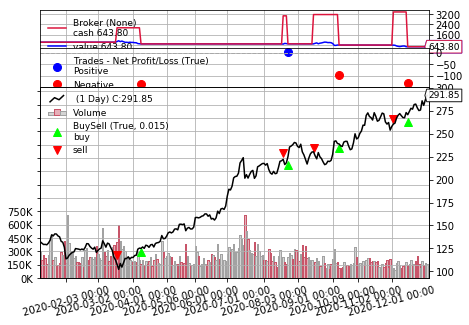

Final Portfolio Value: 643.80
Final Cash Value: 643.80
——————————————

Stock: 002677.SZ
Starting Portfolio Value: 1000.00
2020-02-26, Buy order filled at price: 12.29
2020-03-17, Sell order filled at price: 11.51
2020-04-10, Buy order filled at price: 11.58
2020-04-24, Sell order filled at price: 11.26
2020-05-19, Buy order filled at price: 11.38
2020-05-27, Sell order filled at price: 10.74
2020-06-09, Buy order filled at price: 10.79
2020-06-22, Sell order filled at price: 11.11
2020-06-29, Buy order filled at price: 11.4
2020-09-22, Sell order filled at price: 19.01
2020-11-02, Buy order filled at price: 18.99
2020-11-16, Sell order filled at price: 17.5
2020-12-14, Buy order filled at price: 16.45
2020-12-22, Sell order filled at price: 16.6


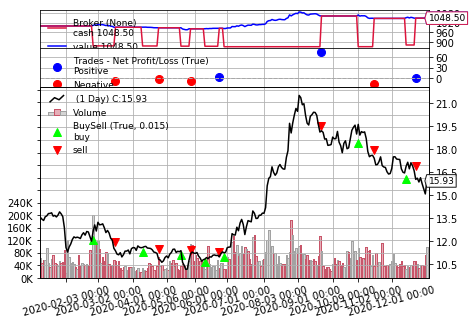

Final Portfolio Value: 1048.50
Final Cash Value: 1048.50
——————————————

Stock: 600809.SH
Starting Portfolio Value: 1000.00
2020-02-25, Buy order filled at price: 86.97
2020-03-20, Sell order filled at price: 81.45
2020-04-07, Buy order filled at price: 91.81
2020-08-18, Sell order filled at price: 171.01
2020-10-09, Sell order filled at price: 201.05
2020-10-14, Buy order filled at price: 221.19
2020-12-07, Sell order filled at price: 262.95
2020-12-14, Buy order filled at price: 289.9


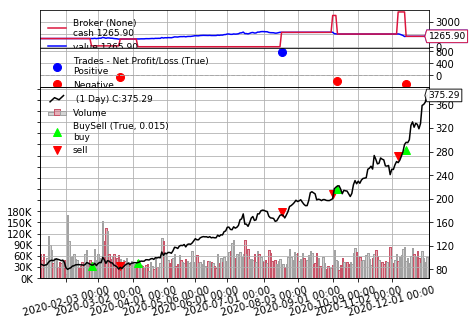

Final Portfolio Value: 1265.90
Final Cash Value: 1265.90
——————————————



In [31]:
from datetime import datetime
a=0
columns = ["tscode","name","industry","Total Return","Annualized Return","The win/loss ratio",
           "Percent Profitable","Maximum Drawdown","Sharpe Ratio","whether successful"]
df_result = pd.DataFrame(columns=columns)
for i in range(len(stock_ts_code)):
    tscode = stock_ts_code[i]
    df_industry = pro.stock_basic(ts_code=tscode, fields=['ts_code','name','industry'])
    df1 = pro.daily(**{"ts_code": tscode, "start_date": 20200101, "end_date": 20210101,}, 
        fields=["ts_code", "trade_date", "open", "high", "low", "close", "vol"])
    
    #The index of df is in reverse chronological order, we arrange it in positive time order here, and set trade day as index
    df1=df1.iloc[::-1].reset_index(drop = True)
    df1['trade_date'] = df1['trade_date'].values.astype(str)
    df1['trade_date'] = pd.to_datetime(df1['trade_date'])
    df1 = df1.set_index('trade_date')
    
    #Use backtrader to do the backtest
    pandasdata = bt.feeds.PandasDirectData(dataname=df1,                                  
                                       fromdate=datetime(2020, 1, 1),                                  
                                       todate=datetime(2021, 1, 1, 0, 0, 0),                                  
                                       datetime=0,                                  
                                       dtformat='%Y-%m-%d',                                  
                                       open=2,high=3,low=4,close=5,volume=6,nullvalue=0.0,reverse=False)
    if __name__ == '__main__':
        print(f"Stock: {tscode}")
        cerebro = bt.Cerebro()
        #Set up initial capital
        cerebro.broker.setcash(1000.000)
        #Add stock data
        cerebro.adddata(pandasdata)
        print('Starting Portfolio Value: %.2f' % cerebro.broker.getvalue())
        #Add stratety
        cerebro.addstrategy(SMACrossoverStrategy)
        #Go through the data for that stock
        cerebro.run()
        #Draw the picture
        cerebro.plot(iplot = False)

        print('Final Portfolio Value: %.2f' % cerebro.broker.getvalue())
        print('Final Cash Value: %.2f' % cerebro.broker.getcash())
        print('——————————————\n')
    
    #The position dataframe is proposed and merged with the original stock data
    position_data = cerebro.runstrats[0][0].position_df 
    position_data = position_data.set_index('datetime') #Set datetime to the index of position
    df_merged = df1.merge(position_data, how='left', left_index=True, right_index=True, suffixes=('_df1', '_position_data'))

    #Assign the position at the time of opening to 1 and the rest to 0
    for index, row in df_merged.iterrows():
        if df_merged.loc[index,'position'] != 0 and df_merged.shift(1).at[index,'position'] == 1:
            df_merged.loc[index,'position'] = 1
    df_merged = df_merged.fillna(0)
    
# '''
#   Calculate Evaluation Criteria

    #Strategy performance
    df_merged['DailyReturn'] = df_merged['close'].pct_change() * df_merged['position'].shift(1)  
    df_merged[df_merged['DailyReturn'] != 0]
    #Total return
    total_return = (df_merged["DailyReturn"] + 1).prod() - 1
    #Annualized return
    annualized_return = (total_return + 1) ** (252 / len(df_merged.index)) - 1
    #Win/Loss ratio
    winning_trades = len(df_merged[df_merged["DailyReturn"] > 0]) 
    losing_trades = len(df_merged[df_merged["DailyReturn"] < 0])
    win_loss_ratio = winning_trades/losing_trades
    #Percent profitable
    percent_profitable = winning_trades / (winning_trades + losing_trades) if (winning_trades + losing_trades) != 0 else np.nan
    #Maximum drawdown
    value = (1+df_merged["DailyReturn"]).cumprod() 
    max_value_till_now = value.cummax() 
    max_drawdown = (value - max_value_till_now).min()
    #Sharpe ratio
    annualized_vol = df_merged["DailyReturn"].std() * np.sqrt(252) 
    sharpe_ratio = (annualized_return - 0.03) / annualized_vol
    
# ''' 
    #If the annualized return is greater than zero, the selected stock are considered reasonable
    #Calculate the number of profitable stocks
    if annualized_return > 0.025:  #risk-free rate:0.025
        vote = "Congratulations!"
        a += 1
    else:
        vote = "Unfortunately"

    df_result = df_result.append({"tscode":df_industry["ts_code"][0],"name":df_industry["name"][0],
                                  "industry":df_industry["industry"][0],"Total Return":total_return,
                                  "Annualized Return":annualized_return, "The win/loss ratio":win_loss_ratio,
                                  "Percent Profitable":percent_profitable, "Maximum Drawdown":max_drawdown,
                                  "Sharpe Ratio":sharpe_ratio, "whether successful":vote},ignore_index=True)

### Results presentation

In [32]:
df_result 

,tscode,name,industry,Total Return,Annualized Return,The win/loss ratio,Percent Profitable,Maximum Drawdown,Sharpe Ratio,whether successful
0,000858.SZ,五粮液,白酒,1.139141,1.200242,1.830189,0.646667,-0.185690,4.203476,Congratulations!
1,002677.SZ,浙江美大,家用电器,0.201116,0.209296,0.916667,0.478261,-0.396677,0.595713,Congratulations!
2,600809.SH,山西汾酒,白酒,1.704082,1.805567,1.257143,0.556962,-0.265389,4.479197,Congratulations!


### Calculate the mean of the Annualized Return

In [27]:
df_result["Annualized Return"].describe()["mean"]

1.0717014237083717

### Calculate the Ratio

**Ratio:** The percentage of stocks with a total return higher than the risk-free rate in a SMA trading strategy

In [33]:
success_rate= a/len(stock_ts_code)
print(f"{success_rate:.2%} of the stocks were seccessfully profitable in the backtesting.")

100.00% of the stocks were seccessfully profitable in the backtesting.


# <center>---  Comparative Analysis of Backtest  ---<center>

###  Comparative Analysis
- **Random Stock Selection:** Randomly select 30 groups of stocks with the same number of the selected stocks from the pre-treated stocks, a total of 150 stocks
- **Operation Strategy** 
- **Calculate and the Mean of Return Ratio**
- **Compare Backtest Strategies:** Compare the results of random stock selection with those of strategic stock selection

### Random Stock Selection

In [36]:
import random

### Operation Strategy

In [38]:
columns = ["tscode","name","industry","Total Return","Annualized Return","The win/loss ratio",
           "Percent Profitable","Maximum Drawdown","Sharpe Ratio","whether successful"]
df_result2 = pd.DataFrame(columns=columns)

In [45]:
test=[]
for i in range(50):
    stock_ts_code_random = []
    list = range(1,len(all_stock))
    random_num = random.sample(list,len(stock_ts_code))
    for num in random_num:
        stock_ts_code_random.append(all_stock[num])
    
    b = 0
    for i in range(len(stock_ts_code_random)):
        tscode = stock_ts_code_random[i]
        df2 = pro.daily(**{"ts_code": tscode, "start_date": 20200101, "end_date": 20210101,}, 
            fields=["ts_code", "trade_date", "open", "high", "low", "close", "vol"])

        #The index of df is in reverse chronological order, we arrange it in positive time order here, and set trade day as index
        df2=df2.iloc[::-1].reset_index(drop = True)
        df2['trade_date'] = df2['trade_date'].values.astype(str)
        df2['trade_date'] = pd.to_datetime(df2['trade_date'])
        df2 = df2.set_index('trade_date')

        #Use backtrader to do the backtest
        pandasdata = bt.feeds.PandasDirectData(dataname=df2,                                  
                                           fromdate=datetime(2020, 1, 1),                                  
                                           todate=datetime(2021, 1, 1, 0, 0, 0),                                  
                                           datetime=0,                                  
                                           dtformat='%Y-%m-%d',                                  
                                           open=2,high=3,low=4,close=5,volume=6,nullvalue=0.0,reverse=False)
        if __name__ == '__main__':
            print(f"Stock: {tscode}")
            cerebro = bt.Cerebro()
            #Set up initial capital
            cerebro.broker.setcash(1000.000)
            #Add stock data
            cerebro.adddata(pandasdata)
            print('Starting Portfolio Value: %.2f' % cerebro.broker.getvalue())
            #Add stratety
            cerebro.addstrategy(SMACrossoverStrategy)
            #Go through the data for that stock
            cerebro.run()

            print('Final Portfolio Value: %.2f' % cerebro.broker.getvalue())
            print('Final Cash Value: %.2f' % cerebro.broker.getcash())
            print('——————————————\n')

        #The position dataframe is proposed and merged with the original stock data
        position_data = cerebro.runstrats[0][0].position_df 
        position_data = position_data.set_index('datetime') #将datetime设为position的index
        df_merged = df2.merge(position_data, how='left', left_index=True, right_index=True, suffixes=('_df2', '_position_data'))

        #Assign the position at the time of opening to 1 and the rest to 0
        for index, row in df_merged.iterrows():
            if df_merged.loc[index,'position'] != 0 and df_merged.shift(1).at[index,'position'] == 1:
                df_merged.loc[index,'position'] = 1
        df_merged = df_merged.fillna(0)

    # '''
    #   Calculate Evaluation Criteria

        #Strategy performance
        df_merged['DailyReturn'] = df_merged['close'].pct_change() * df_merged['position'].shift(1)  
        df_merged[df_merged['DailyReturn'] != 0]
        #total return
        total_return = (df_merged["DailyReturn"] + 1).prod() - 1
        #annualized return
        annualized_return = (total_return + 1) ** (252 / len(df_merged.index)) - 1
        #win loss ratio
        winning_trades = len(df_merged[df_merged["DailyReturn"] > 0]) 
        losing_trades = len(df_merged[df_merged["DailyReturn"] < 0])
        win_loss_ratio = winning_trades/losing_trades if losing_trades != 0 else np.nan
        #percent profitable
        percent_profitable = winning_trades / (winning_trades + losing_trades) if (winning_trades + losing_trades) != 0 else np.nan
        #Maximum Drawdown
        value = (1+df_merged["DailyReturn"]).cumprod() 
        max_value_till_now = value.cummax() 
        max_drawdown = (value - max_value_till_now).min()
        #Sharpe Ratio
        annualized_vol = df_merged["DailyReturn"].std() * np.sqrt(252) 
        sharpe_ratio = (annualized_return - 0.03) / annualized_vol

    # ''' 
        #If the annualized return is greater than zero, the selected stock are considered reasonable
        #Calculate the number of profitable stocks
        if annualized_return > 0.025:
            vote = "Congratulations!"
            b += 1
        else:
            vote = "Unfortunately"
            
    success_rate2= b/len(stock_ts_code_random)
    print(f"{success_rate2:.2%} of the stocks were seccessfully profitable in the backtesting")
    test.append(success_rate2)
    
    df_result2 = df_result2.append({"tscode":df_industry["ts_code"][0],"name":df_industry["name"][0],
                                  "industry":df_industry["industry"][0],"Total Return":total_return,
                                  "Annualized Return":annualized_return, "The win/loss ratio":win_loss_ratio,
                                  "Percent Profitable":percent_profitable, "Maximum Drawdown":max_drawdown,
                                  "Sharpe Ratio":sharpe_ratio, "whether successful":vote},ignore_index=True)

Stock: 600593.SH
Starting Portfolio Value: 1000.00
2020-02-27, Buy order filled at price: 39.3
2020-03-10, Sell order filled at price: 39.08
2020-04-03, Buy order filled at price: 39.8
2020-05-25, Sell order filled at price: 42.27
2020-06-29, Buy order filled at price: 42.05
2020-07-07, Sell order filled at price: 39.64
2020-07-21, Buy order filled at price: 44.0
2020-08-03, Sell order filled at price: 40.95
2020-08-17, Buy order filled at price: 42.04
2020-08-27, Sell order filled at price: 40.11
2020-09-15, Buy order filled at price: 41.09
2020-11-09, Sell order filled at price: 42.78
2020-11-24, Buy order filled at price: 42.59
2020-11-30, Sell order filled at price: 42.2
Final Portfolio Value: 961.60
Final Cash Value: 961.60
——————————————

Stock: 600425.SH
Starting Portfolio Value: 1000.00
2020-02-25, Buy order filled at price: 3.7299999999999995
2020-03-20, Sell order filled at price: 3.8899999999999997
2020-04-21, Buy order filled at price: 3.9200000000000004
2020-06-01, Sell or

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:78: RuntimeWarning: divide by zero encountered in double_scalars


Stock: 000004.SZ
Starting Portfolio Value: 1000.00
2020-02-20, Buy order filled at price: 29.369999999999997
2020-03-19, Sell order filled at price: 34.51
2020-05-15, Buy order filled at price: 33.0
2020-05-29, Sell order filled at price: 28.28
2020-06-17, Buy order filled at price: 28.9
2020-06-22, Sell order filled at price: 28.96
2020-06-29, Buy order filled at price: 28.380000000000003
2020-07-27, Sell order filled at price: 28.630000000000003
2020-10-09, Buy order filled at price: 23.29
2020-10-13, Sell order filled at price: 24.17
2020-10-16, Buy order filled at price: 24.88
2020-12-04, Sell order filled at price: 26.3
Final Portfolio Value: 1030.30
Final Cash Value: 1030.30
——————————————

Stock: 601000.SH
Starting Portfolio Value: 1000.00
2020-02-27, Buy order filled at price: 2.34
2020-03-19, Sell order filled at price: 2.23
2020-04-27, Buy order filled at price: 2.28
2020-05-25, Sell order filled at price: 2.23
2020-06-09, Buy order filled at price: 2.28
2020-06-12, Sell orde

### Calculate the mean of the Annualized Return

In [46]:
df_result2["Annualized Return"].describe()["mean"]

0.02536284135872075

### Calculate Ratio

In [47]:
success_ratio = sum(test)/len(test)
success_ratio

0.38000000000000006

### Compare Backtest Strategies

#### Only about <font color=#FF0000>35%</font> of the total return rates of randomly selected stocks exceed the risk-free rate, with an average annualized return rate of only <font color=#FF0000>2.53%</font>, much lower than the results of the strategy stock selection. This proves the effectiveness of the stock selection strategy in this study.

# <center>---  Summary  ---<center>

### Conclusion
This study conducted an empirical research by selecting and extracting financial data and market data of some listed companies in the A-share market in China from January 1, 2019, to January 1, 2020, to construct a quantitative stock trading strategy based on **fundamental factors** and **technical indicators**. Firstly, fundamental factors such as **basic items and derived factors, per share indicators, and value factors** were selected. Through winsorization and scoring by quartile method, companies with strong financial health, profitability, operational efficiency, and stable financial structure were screened. Then, stocks were evaluated from different dimensions using technical indicator factors such as **SMA, MACD, RSI, MFI, APO, WILLR, ATR, and BOLL** to select three stocks suitable for the **SMA strategy** for buying. Finally, to validate this stock selection result, backtesting of the selected stocks from January 1, 2020, to January 1, 2021, using the SMA strategy was conducted, and the **backtesting results** were compared with those of randomly selected stocks to demonstrate the effectiveness of the stock selection strategy in this study.

### Lack of comprehensive risk assessment
Although fundamental and technical indicators have been taken into account, the lack of a comprehensive risk assessment mechanism may lead to insufficient understanding of market and company-specific risks.
- **Limitations of portfolio optimization:**
 While portfolio optimization has been mentioned, the specific methods and weight allocation have not been detailed, potentially resulting in unscientific and ineffective portfolio construction.
- **Criteria for selection may need to be strengthened:**
 There may be some subjectivity in the selection of fundamental factors and technical indicators, requiring further refinement and adjustment of selection criteria to reduce randomness and enhance the universality of the strategy.
- **Industry analysis may not be thorough enough:**
 Although industry analysis has been mentioned, specific methods and bases have not been outlined, which could lead to inaccurate or incomplete industry selection.
- **Failure to consider trading costs and slippage:**
 Neglecting actual trading costs and slippage in backtesting may result in an overly optimistic assessment of the strategy's effectiveness.

### Prospect
- **Enhancing comprehensive risk assessment:**
 Introduce risk assessment mechanisms with more dimensions, such as market risk, industry risk, company risk, etc., to comprehensively grasp investment risks.
- **Portfolio optimization methods:**
 Explore scientifically effective portfolio methods applied to selected multiple stocks, such as asset allocation models, Markowitz portfolio optimization models, etc., to achieve risk diversification and better returns.
- **Quantification and automation of selection criteria:**
 Utilize data mining and machine learning technologies to improve the accuracy and universality of stock selection strategies.
- **Industry analysis:**
 Combine industry trends and macroeconomic data to select stocks, more accurately grasp industry development trends and individual stock performance, improve stock selection accuracy and investment success rate, and achieve a more robust investment return.
- **Consideration of trading costs and slippage:**
 Take into account actual trading costs and slippage in backtesting to more realistically evaluate the effectiveness of the strategy and potentially take corresponding optimization measures.

Through these improvement measures, we may enhance the overall effectiveness of the stock selection strategy, enabling the strategy to yield positive results in a more volatile market environment as well.

---

## <center>-----------------------------------------------------------  The End  -----------------------------------------------------------</center>